<a href="https://colab.research.google.com/github/lidimoura/challenge2-dataScience-TelecomX/blob/main/Challenge2_dataScience_TelecomX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Challenge 2 Data Science - Telecom X**

## Extração de dados

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

In [3]:
# Extraindo os dados da nossa base de dados criando um DataFrame
df = pd.read_json(url)

In [4]:
# Verificando as informações gerais do nosso df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
#Verificando a estrutura dos dados do df
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Transformação

In [6]:
import requests

# Extração do zero
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
df_telecom = pd.json_normalize(requests.get(url).json())

print(" ANTES: Como as colunas chegaram da API:")
print(df_telecom[['customer.gender', 'account.Contract', 'Churn']].head(2))
print("-" * 50)

# Tratamento e Tradução
df_telecom = df_telecom[df_telecom['Churn'].isin(['Yes', 'No'])]

colunas_ptbr = {
    'customer.gender': 'genero', 'customer.SeniorCitizen': 'idoso',
    'customer.Partner': 'possui_parceiro', 'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'meses_contrato', 'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas', 'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online', 'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo', 'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv', 'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato', 'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento', 'account.Charges.Monthly': 'gasto_mensal',
    'account.Charges.Total': 'gasto_total'
}
df_telecom = df_telecom.rename(columns=colunas_ptbr)

mapeamento_valores = {
    'Yes': 'Sim', 'No': 'Não', 'Female': 'Feminino', 'Male': 'Masculino',
    'Month-to-month': 'Mensal', 'One year': 'Anual', 'Two year': 'Bienal',
    'No internet service': 'Sem internet', 'No phone service': 'Sem telefone',
    'Electronic check': 'Cheque eletrônico', 'Mailed check': 'Cheque enviado',
    'Bank transfer (automatic)': 'Transferência bancária', 'Credit card (automatic)': 'Cartão de crédito'
}
df_telecom = df_telecom.replace(mapeamento_valores)

# Finanças e Limpeza final
df_telecom['gasto_total'] = pd.to_numeric(df_telecom['gasto_total'], errors='coerce').fillna(0)
df_telecom['gasto_diario'] = round(df_telecom['gasto_mensal'] / 30, 2)
if 'customerID' in df_telecom.columns:
    df_telecom = df_telecom.drop(columns=['customerID'])

print(" DEPOIS: Como os dados ficaram após a nossa transformação:")
display(df_telecom[['genero', 'tipo_contrato', 'metodo_pagamento', 'Churn']].head(2))

 ANTES: Como as colunas chegaram da API:
  customer.gender account.Contract Churn
0          Female         One year    No
1            Male   Month-to-month    No
--------------------------------------------------
 DEPOIS: Como os dados ficaram após a nossa transformação:


,genero,tipo_contrato,metodo_pagamento,Churn
0,Feminino,Anual,Cheque enviado,Não
1,Masculino,Mensal,Cheque enviado,Não


In [7]:
# Diagnóstico dos Dados

print("1. Verificando Valores Nulos (NaN):")
display(df_telecom.isnull().sum())

print("\n2. Verificando Espaços em Branco (strings vazias):")
# Verificamos em todas as colunas se existe apenas um espaço " "
espacos_em_branco = (df_telecom == " ").sum()
display(espacos_em_branco[espacos_em_branco > 0])

print("\n3. Verificando Linhas Duplicadas:")
print(f"Total de duplicados: {df_telecom.duplicated().sum()}")

print("\n4. Valores únicos na variável alvo (Churn):")
print(df_telecom['Churn'].unique())

1. Verificando Valores Nulos (NaN):


,0
Churn,0
genero,0
idoso,0
possui_parceiro,0
possui_dependentes,0
meses_contrato,0
servico_telefone,0
multiplas_linhas,0
tipo_internet,0
seguranca_online,0



2. Verificando Espaços em Branco (strings vazias):


,0



3. Verificando Linhas Duplicadas:
Total de duplicados: 22

4. Valores únicos na variável alvo (Churn):
['Não' 'Sim']


In [8]:
# Substituindo os espaços em branco por '0' para permitir a conta
df_telecom['gasto_total'] = df_telecom['gasto_total'].replace(" ", "0")

# Convertendo a coluna para número (float)
df_telecom['gasto_total'] = pd.to_numeric(df_telecom['gasto_total'])

# Verificando se agora a tipagem está correta
print(f"Tipo da coluna gasto_total: {df_telecom['gasto_total'].dtype}")

Tipo da coluna gasto_total: float64


## Carregamento e análise

In [9]:
# Garantindo que o gasto mensal seja numérico (float)
df_telecom['gasto_mensal'] = pd.to_numeric(df_telecom['gasto_mensal'], errors='coerce')

# Criando a coluna de gasto diário conforme solicitado no Trello
# Arredondamos para 2 casas decimais para manter o padrão monetário
df_telecom['gasto_diario'] = (df_telecom['gasto_mensal'] / 30).round(2)

# Conferindo o resultado das colunas financeiras
print("Estatísticas das colunas financeiras:")
display(df_telecom[['gasto_mensal', 'gasto_total', 'gasto_diario']].describe())

Estatísticas das colunas financeiras:


,gasto_mensal,gasto_total,gasto_diario
count,7043.000000,7043.000000,7043.000000
mean,64.761692,2279.734304,2.158675
std,30.090047,2266.794470,1.003088
min,18.250000,0.000000,0.610000
25%,35.500000,398.550000,1.180000
50%,70.350000,1394.550000,2.340000
75%,89.850000,3786.600000,2.990000
max,118.750000,8684.800000,3.960000


In [10]:
import plotly.express as px

# Criando o gráfico de barras para a distribuição global do Churn, usando o parâmetro 'text_auto=True' para exibir os números exatos sobre as barras
fig_geral = px.histogram(df_telecom,
                         x="Churn",
                         title="Panorama Geral de Evasão de Clientes",
                         text_auto=True,
                         color="Churn",
                         color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'})

fig_geral.update_layout(xaxis_title="O cliente saiu?", yaxis_title="Quantidade de Clientes")
fig_geral.show()

In [11]:

# Panorama Geral da Evasão (Churn)
fig_geral = px.pie(df_telecom, names='Churn',
             title='Proporção Geral de Evasão (Churn)',
             color='Churn',
             color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'},
             hole=0.4) # Gráfico de rosca para um visual moderno
fig_geral.show()

# Ajuste rápido para a coluna 'idoso' (0/1 para Não/Sim)
df_telecom['idoso'] = df_telecom['idoso'].replace({0: 'Não', 1: 'Sim'})

# Análise das variáveis explicativas
# Lista das variáveis que o Trello e a supervisão sugerem analisar
variaveis = ['genero', 'idoso', 'possui_parceiro', 'possui_dependentes', 'tipo_contrato', 'metodo_pagamento']

for col in variaveis:
    fig = px.histogram(df_telecom,
                        x=col,
                        color="Churn",
                        barmode="group",
                        title=f"Evasão de Clientes por {col.replace('_', ' ').capitalize()}",
                        text_auto=True,
                        color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'})

    fig.update_layout(xaxis_title=col.replace('_', ' ').capitalize(),
                      yaxis_title="Quantidade de Clientes")
    fig.show()

In [12]:
# Gráfico por Meses de Contrato (Tempo numérico)
# Aqui usamos 'nbins' para agrupar os meses e não ficar poluído
fig_meses = px.histogram(df_telecom,
                         x="meses_contrato",
                         color="Churn",
                         barmode="group",
                         title="Evasão por meses de contrato (Tempo)",
                         nbins=12,
                         color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'})
fig_meses.show()


In [13]:
# Realizando análise descritiva
df_telecom.describe()

,meses_contrato,gasto_mensal,gasto_total,gasto_diario
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


In [14]:
# Analisando as estatísticas de tempo e gastos comparando quem saiu e quem ficou
# Usamos o .T para transpor a tabela, deixando a leitura mais fácil
resumo_churn = df_telecom.groupby('Churn')[['meses_contrato', 'gasto_mensal']].describe().T
display(resumo_churn)

Churn                         Não          Sim
meses_contrato count  5174.000000  1869.000000
               mean     37.569965    17.979133
               std      24.113777    19.531123
               min       0.000000     1.000000
               25%      15.000000     2.000000
               50%      38.000000    10.000000
               75%      61.000000    29.000000
               max      72.000000    72.000000
gasto_mensal   count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000

In [15]:
# 1. Boxplot de Gasto Mensal por Churn
fig_gasto = px.box(df_telecom,
                   x="Churn",
                   y="gasto_mensal",
                   color="Churn",
                   points="all", # Mostra os pontos individuais para ver a densidade
                   title="Distribuição de Gasto Mensal: Quem Fica vs. Quem Sai",
                   color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'})

fig_gasto.update_layout(xaxis_title="O cliente saiu?", yaxis_title="Gasto Mensal (R$)")
fig_gasto.show()

# 2. Boxplot de Meses de Contrato por Churn
fig_meses = px.box(df_telecom,
                   x="Churn",
                   y="meses_contrato",
                   color="Churn",
                   points="all",
                   title="Distribuição de Tempo de Contrato: Quem Fica vs. Quem Sai",
                   color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'})

fig_meses.update_layout(xaxis_title="O cliente saiu?", yaxis_title="Meses de Contrato")
fig_meses.show()

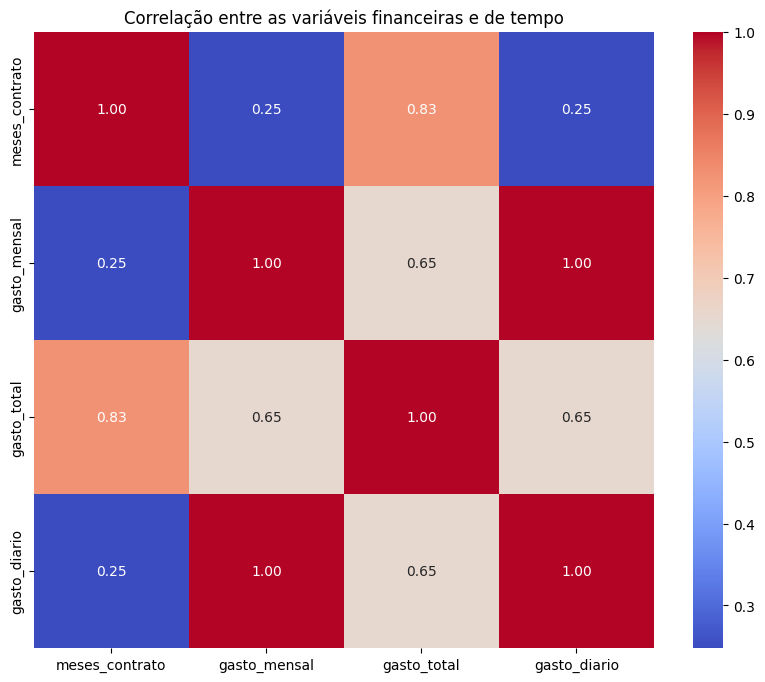

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando apenas as colunas numéricas para a correlação
corr = df_telecom[['meses_contrato', 'gasto_mensal', 'gasto_total', 'gasto_diario']].corr()

# Criando o mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre as variáveis financeiras e de tempo')
plt.show()

In [17]:
# 1. Criando uma cópia do DF para não estragar o que já fizemos
df_modelagem = df_telecom.copy()

# 2. Transformando variáveis de duas opções (Binárias) em 0 e 1
# Vamos focar no Churn, idoso, e outras de Sim/Não
cols_binarias = ['Churn', 'genero', 'idoso', 'possui_parceiro', 'possui_dependentes', 'servico_telefone', 'fatura_digital']

# Mapeamento rápido: Sim = 1, Não = 0 | Masculino = 1, Feminino = 0
mapeamento = {'Sim': 1, 'Não': 0, 'Masculino': 1, 'Feminino': 0}

for col in cols_binarias:
    df_modelagem[col] = df_modelagem[col].replace(mapeamento)

# 3. One-Hot Encoding para as colunas com várias opções (tipo_contrato, metodo_pagamento, etc)
# O get_dummies cria uma nova coluna para cada opção!
df_modelagem = pd.get_dummies(df_modelagem, columns=['tipo_contrato', 'metodo_pagamento', 'tipo_internet'])

# Visualizando como os dados ficaram "numéricos"
display(df_modelagem.head())

/tmp/ipykernel_34021/1424850368.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_modelagem[col] = df_modelagem[col].replace(mapeamento)


,Churn,genero,idoso,possui_parceiro,possui_dependentes,meses_contrato,servico_telefone,multiplas_linhas,seguranca_online,backup_online,...,tipo_contrato_Anual,tipo_contrato_Bienal,tipo_contrato_Mensal,metodo_pagamento_Cartão de crédito,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária,tipo_internet_DSL,tipo_internet_Fiber optic,tipo_internet_Não
0,0,0,0,1,1,9,1,Não,Não,Sim,...,True,False,False,False,False,True,False,True,False,False
1,0,1,0,0,0,9,1,Sim,Não,Não,...,False,False,True,False,False,True,False,True,False,False
2,1,1,0,0,0,4,1,Não,Não,Não,...,False,False,True,False,True,False,False,False,True,False
3,1,1,1,1,0,13,1,Não,Não,Sim,...,False,False,True,False,True,False,False,False,True,False
4,1,0,1,1,0,3,1,Não,Não,Não,...,False,False,True,False,False,True,False,False,True,False


In [18]:
# Criando o DataFrame para modelagem com get_dummies
# O segredo aqui é o .astype(int) no final para garantir 1 e 0
df_modelagem = pd.get_dummies(df_telecom, columns=[
    'genero', 'idoso', 'possui_parceiro', 'possui_dependentes',
    'servico_telefone', 'multiplas_linhas', 'tipo_internet',
    'seguranca_online', 'backup_online', 'protecao_dispositivo',
    'suporte_tecnico', 'streaming_tv', 'streaming_filmes',
    'tipo_contrato', 'fatura_digital', 'metodo_pagamento'
]).astype(int, errors='ignore') # Converte True/False para 1/0

# Garantindo que o Churn (nossa variável alvo) seja 1 e 0
df_modelagem['Churn'] = df_modelagem['Churn'].replace({'Sim': 1, 'Não': 0}).astype(int)


/tmp/ipykernel_34021/1705790564.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_modelagem['Churn'] = df_modelagem['Churn'].replace({'Sim': 1, 'Não': 0}).astype(int)


In [19]:

# Garantindo que o DataFrame de modelagem está pronto  para a correlação
df_modelagem = pd.get_dummies(df_telecom, columns=[
    'genero', 'idoso', 'possui_parceiro', 'possui_dependentes',
    'servico_telefone', 'multiplas_linhas', 'tipo_internet',
    'seguranca_online', 'backup_online', 'protecao_dispositivo',
    'suporte_tecnico', 'streaming_tv', 'streaming_filmes',
    'tipo_contrato', 'fatura_digital', 'metodo_pagamento'
]).astype(int, errors='ignore')

if 'Churn' in df_modelagem.columns:
    df_modelagem['Churn'] = df_modelagem['Churn'].replace({'Sim': 1, 'Não': 0}).astype(int)

# Criando a variável de correlação
correlacao_churn = df_modelagem.corr()['Churn'].sort_values(ascending=False)



/tmp/ipykernel_34021/4283246420.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_modelagem['Churn'] = df_modelagem['Churn'].replace({'Sim': 1, 'Não': 0}).astype(int)


In [20]:
# --- GERAÇÃO E EXPORTAÇÃO DOS GRÁFICOS ---

# Instalando kaleido e atualizando plotly, se necessário, para salvar imagens
!pip install -U kaleido
!pip install -U plotly>=6.1.1

# Instalando o Chrome para o Kaleido (dependência)
!plotly_get_chrome

# Instalando dependências adicionais para o Chrome (comum em ambientes slim)
!sudo apt update && sudo apt-get install -y libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

# GRAFICO 1: Evasão por Tempo
fig_meses = px.histogram(df_telecom,
                         x="meses_contrato",
                         color="Churn",
                         barmode="group",
                         title="Evasão por Meses de Contrato",
                         nbins=12,
                         color_discrete_map={'Sim': '#d62728', 'Não': '#1f77b4'})
fig_meses.write_image("churn_tempo_contrato.png")
fig_meses.show()

# GRAFICO 2: Correlação
top_corr = correlacao_churn.head(10).tolist() + correlacao_churn.tail(10).tolist()
df_corr_top = correlacao_churn.loc[correlacao_churn.isin(top_corr)].sort_values(ascending=True)

fig_corr = px.bar(df_corr_top,
                   orientation='h',
                   title="Fatores Críticos: O que retém vs. O que afasta o cliente",
                   color=df_corr_top.values,
                   color_continuous_scale='Electric')
fig_corr.write_image("correlacao_churn.png")
fig_corr.show()

print("✅ Sucesso! Os arquivos 'churn_tempo_contrato.png' e 'correlacao_churn.png' estão na pasta lateral.")


Plotly will install a copy of Google Chrome to be used for generating static images of plots.
Chrome will be installed at: None
Do you want to proceed? [y/n] Y
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.12/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tre

✅ Sucesso! Os arquivos 'churn_tempo_contrato.png' e 'correlacao_churn.png' estão na pasta lateral.


## Relatório final

# **Relatório executivo: Análise de evasão de clientes (Churn) - Telecom X**

Objetivo: Este relatório apresenta uma análise detalhada da base de dados da Telecom X para identificar os principais fatores que levam ao cancelamento de serviços (Churn). O intuito é fornecer subsídios para estratégias de retenção mais assertivas e próspera para o négocio e clientes.


## Metodologia e preparação dos dados

Para garantir a confiabilidade da análise, realizamos as seguintes etapas:

* Extração: Importação de dados via API (JSON).

* Tratamento de inconsistências: Identificamos e corrigimos valores nulos e espaços vazios na coluna de gastos totais.

* Padronização: Tradução de todas as variáveis e categorias para o português (PT-BR), facilitando a leitura por gestores locais.

* Engenharia de dados: Criação da métrica de gasto diário para uma visão mais granular do consumo.


## Visualizações Principais

### Tendência de evasão por tempo
Nesta análise, observamos que o maior volume de cancelamentos ocorre nos meses iniciais.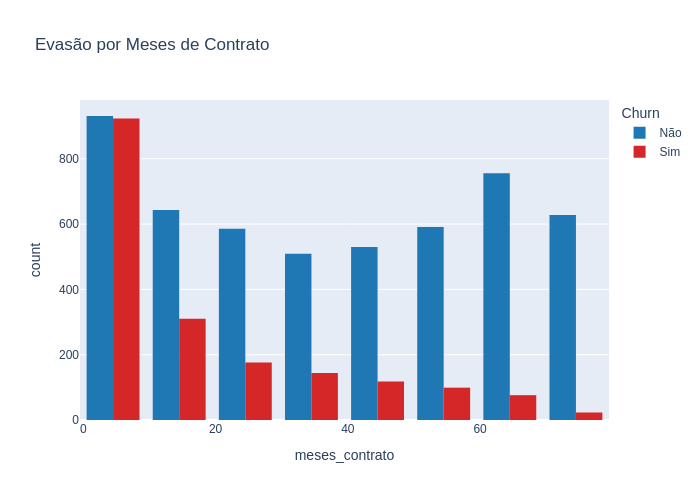

### Fatores de influência (correlação)
O contrato mensal e a falta de serviços adicionais são os maiores preditores de Churn.
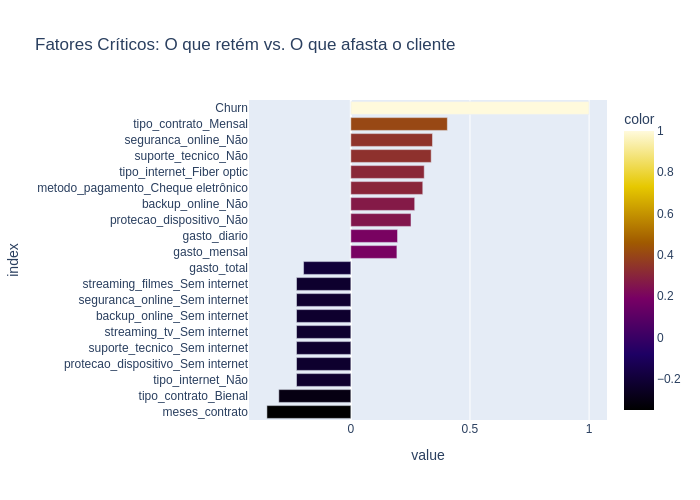

## Principais descobertas (EDA)

Através das visualizações dos gráficos acima identificamos padrões críticos:

* Contratos mensais: Representam o maior volume de cancelamentos.

* O ápice do "Churn": A evasão é extremamente alta nos primeiros 6 meses de contrato.

* Perfil de consumo: Clientes com gastos mensais mais elevados (acima da média de R$ 70,00) tendem a sair mais rápido.

* Falta de serviços adicionais: Clientes sem suporte técnico ou segurança online têm maior propensão à evasão.


## Recomendações estratégicas

Com base nos dados, sugerimos as seguintes ações:

* Retenção no "Onboarding": Implementar descontos agressivos ou meses gratuitos para os primeiros 3 meses de contrato para superar a barreira inicial de saída.

* Upsell de Proteção: Oferecer combos que incluam segurança online e suporte técnico como "benefício" e não como custo extra, aumentando a aderência do cliente ao ecossistema da empresa.

* Migração de Contrato: Criar campanhas para migrar clientes "Mensais" para o plano "Anual" em troca de benefícios exclusivos, reduzindo a volatilidade.